# 六大券商推荐股票投资组合表现分析报告

本报告基于“六大券商合并数据.xlsx”，模拟每个券商投入 100 万元初始资金，并平均分配到推荐股票上的投资表现。分析涵盖收益率、风险指标（方差、VaR）及回撤分析。

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import socket
import matplotlib.font_manager as fm
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# --- 代理自动检测（适配 Clash / V2Ray / SSR 等） ---
def _port_open(port):
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(0.5)
    ok = s.connect_ex(('127.0.0.1', port)) == 0
    s.close()
    return ok

for _port in [7890, 7897, 10809, 8080, 1080, 6152]:
    if _port_open(_port):
        _proxy = f'http://127.0.0.1:{_port}'
        os.environ['http_proxy']  = _proxy
        os.environ['https_proxy'] = _proxy
        print(f"检测到代理，已启用: {_proxy}")
        break
else:
    print("未检测到本地代理，直连网络")

# --- 中文字体设置 ---
def setup_chinese_font():
    for font in ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'Noto Sans CJK SC', 'STHeiti']:
        try:
            plt.rcParams['font.family'] = [font]
            plt.rcParams['axes.unicode_minus'] = False
            return
        except Exception:
            continue

setup_chinese_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'][0])
print("环境准备完成。")

未检测到本地代理，直连网络
环境准备完成。


## 1. 数据读取与初始资金设定

In [20]:
file_path = '六大券商合并数据.xlsx'

df = pd.read_excel(file_path, sheet_name='合并数据')
df['推荐月份'] = pd.to_datetime(df['推荐月份'])

INITIAL_CAPITAL = 1_000_000  # 每家券商初始资金 100 万元
brokers = sorted(df['机构名称'].unique())
print(f"成功读取数据，共 {len(df)} 条记录，涵盖 {len(brokers)} 家券商。")
print(f"券商列表：{brokers}")
print(f"时间范围：{df['推荐月份'].min().strftime('%Y-%m')} ~ {df['推荐月份'].max().strftime('%Y-%m')}")
print(f"初始资金：{INITIAL_CAPITAL:,} 元 / 券商（等权平均分配到当月所有推荐股票）")

成功读取数据，共 889 条记录，涵盖 6 家券商。
券商列表：['中信建投证券', '华泰证券', '天风证券', '平安证券', '开源证券', '招商证券']
时间范围：2025-04 ~ 2026-04
初始资金：1,000,000 元 / 券商（等权平均分配到当月所有推荐股票）


## 2. 月度收益率计算

In [21]:
# 等权重策略：每月将100万均分到该券商当月推荐的所有股票
# 组合月度收益率 = 当月所有推荐股票涨跌幅的算术均值
portfolio_monthly = (
    df.groupby(['机构名称', '推荐月份'])['当月涨跌幅(%)']
    .mean()
    .reset_index()
    .rename(columns={'当月涨跌幅(%)': '月度收益率(%)'})
    .sort_values(['机构名称', '推荐月份'])
    .reset_index(drop=True)
)

print("各券商月度收益率（前12行）：")
display(portfolio_monthly.head(12))
print(f"\n各券商月均收益率汇总：")
display(portfolio_monthly.groupby('机构名称')['月度收益率(%)'].agg(['mean', 'std', 'count']).round(3))

各券商月度收益率（前12行）：


,机构名称,推荐月份,月度收益率(%)
0,中信建投证券,2025-04-30,-3.025080
1,中信建投证券,2025-05-31,2.592150
2,中信建投证券,2025-06-30,7.889000
3,中信建投证券,2025-07-31,7.645000
4,中信建投证券,2025-08-31,17.104656
5,中信建投证券,2025-09-30,-0.635350
6,中信建投证券,2025-10-31,-3.614288
7,中信建投证券,2025-11-30,-1.313686
8,中信建投证券,2025-12-31,7.304657
9,中信建投证券,2026-01-31,8.885500



各券商月均收益率汇总：


,mean,std,count
机构名称,,,
中信建投证券,3.753,6.930,13
华泰证券,5.651,7.078,13
天风证券,3.279,6.211,13
平安证券,3.548,8.528,13
开源证券,4.288,10.719,13
招商证券,4.533,9.625,13


## 3. 13个月累计收益率比较（含上证、深证指数）

Note: you may need to restart the kernel to use updated packages.
正在获取市场基准指数数据（akshare）...
  上证指数 (sh000001): 成功，13 个月
  深证成指 (sz399001): 成功，13 个月


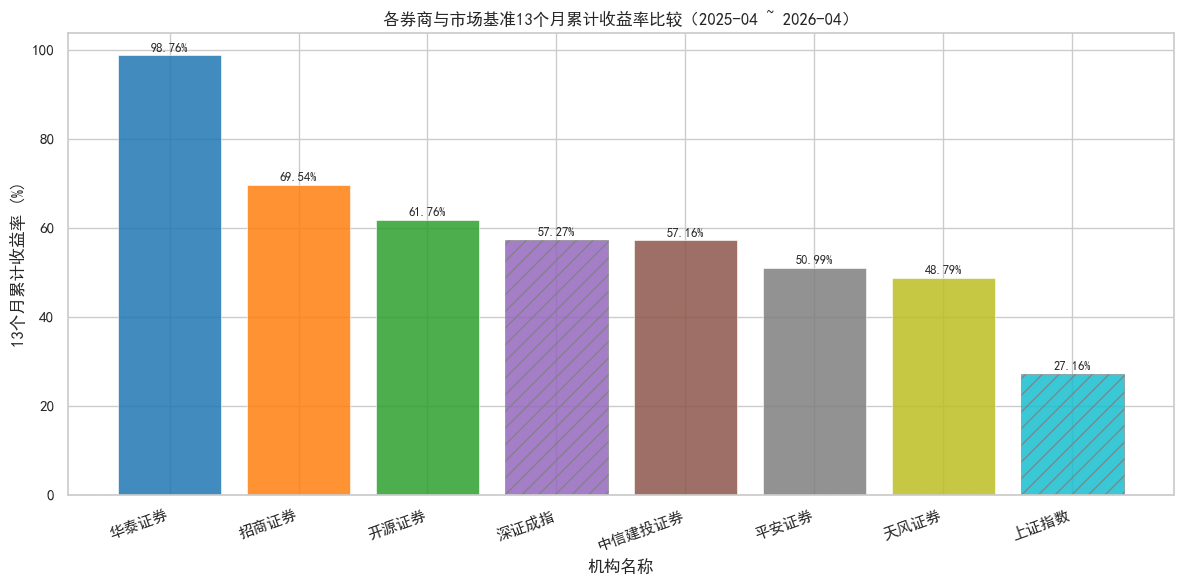


13个月累计收益率汇总：


,机构名称,13个月累计收益率(%)
0,华泰证券,98.756818
1,招商证券,69.543516
2,开源证券,61.759544
3,深证成指,57.274632
4,中信建投证券,57.164214
5,平安证券,50.993931
6,天风证券,48.791404
7,上证指数,27.157627


In [31]:
%pip install akshare -q

import akshare as ak

# ── 使用 akshare 获取A股指数数据（国内可直接访问，无需代理） ──
def fetch_index_monthly_ret(symbol, name, start='2025-04-01'):
    """akshare 下载指数日线 → 月末收盘价 → 月度收益率"""
    try:
        df = ak.stock_zh_index_daily(symbol=symbol)
        df['date'] = pd.to_datetime(df['date'])
        df = df[df['date'] >= pd.Timestamp(start)].set_index('date').sort_index()
        if df.empty:
            raise ValueError("筛选后无数据")
        monthly = df['close'].resample('ME').last()
        ret = monthly.pct_change().dropna() * 100
        ret.index = ret.index.normalize()
        ret.name = name
        print(f"  {name} ({symbol}): 成功，{len(ret)} 个月")
        return ret
    except Exception as e:
        print(f"  {name} ({symbol}): 失败（{e}）")
        return None

print("正在获取市场基准指数数据（akshare）...")
sh_ret = fetch_index_monthly_ret('sh000001', '上证指数')
sz_ret = fetch_index_monthly_ret('sz399001', '深证成指')

# ── 各券商13个月累计收益率（复利，2025-04 ~ 2026-04） ──────────
total_broker = (
    portfolio_monthly.groupby('机构名称')['月度收益率(%)']
    .apply(lambda x: (np.prod(1 + x / 100) - 1) * 100)
    .reset_index()
    .rename(columns={'月度收益率(%)': '13个月累计收益率(%)'})
)

# ── 指数13个月累计收益率 ──────────────────────────────────────
def idx_total_return(idx_ret, label):
    if idx_ret is None:
        return pd.DataFrame()
    ar = (np.prod(1 + idx_ret.values / 100) - 1) * 100
    return pd.DataFrame([{'机构名称': label, '13个月累计收益率(%)': ar}])

total_all = pd.concat(
    [total_broker,
     idx_total_return(sh_ret, '上证指数'),
     idx_total_return(sz_ret, '深证成指')],
    ignore_index=True
).sort_values('13个月累计收益率(%)', ascending=False).reset_index(drop=True)

# ── 可视化 ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = plt.cm.tab10(np.linspace(0, 1, len(total_all)))

bars = ax.bar(
    total_all['机构名称'], total_all['13个月累计收益率(%)'],
    color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5
)
for bar, name in zip(bars, total_all['机构名称']):
    if name in ('上证指数', '深证成指'):
        bar.set_hatch('//')
        bar.set_edgecolor('gray')

for bar, val in zip(bars, total_all['13个月累计收益率(%)']):
    offset = 0.4 if val >= 0 else -1.8
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('机构名称')
ax.set_ylabel('13个月累计收益率 (%)')
ax.set_title('各券商与市场基准13个月累计收益率比较（2025-04 ~ 2026-04）')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\n13个月累计收益率汇总：")
display(total_all)

### 年度收益率分析小结

- **超额收益识别**：以上证指数和深证成指作为市场基准（斜线填充柱），柱高超过基准的券商组合在该年度实现了正向超额收益（Alpha），反之则跑输市场。
- **年际稳定性**：连续多年均跑赢指数的券商，说明其选股体系具备系统性优势，并非偶然；仅某一年表现突出的券商，则需结合市场环境进一步分析其选股逻辑是否可持续。
- **牛熊适应性**：市场整体上行年份，各券商年度收益率均倾向偏高；下行年份的表现差异更能体现真实研究实力——跌幅最小者防御能力最强。

## 4. 月度收益率趋势图（含上证、深证指数）

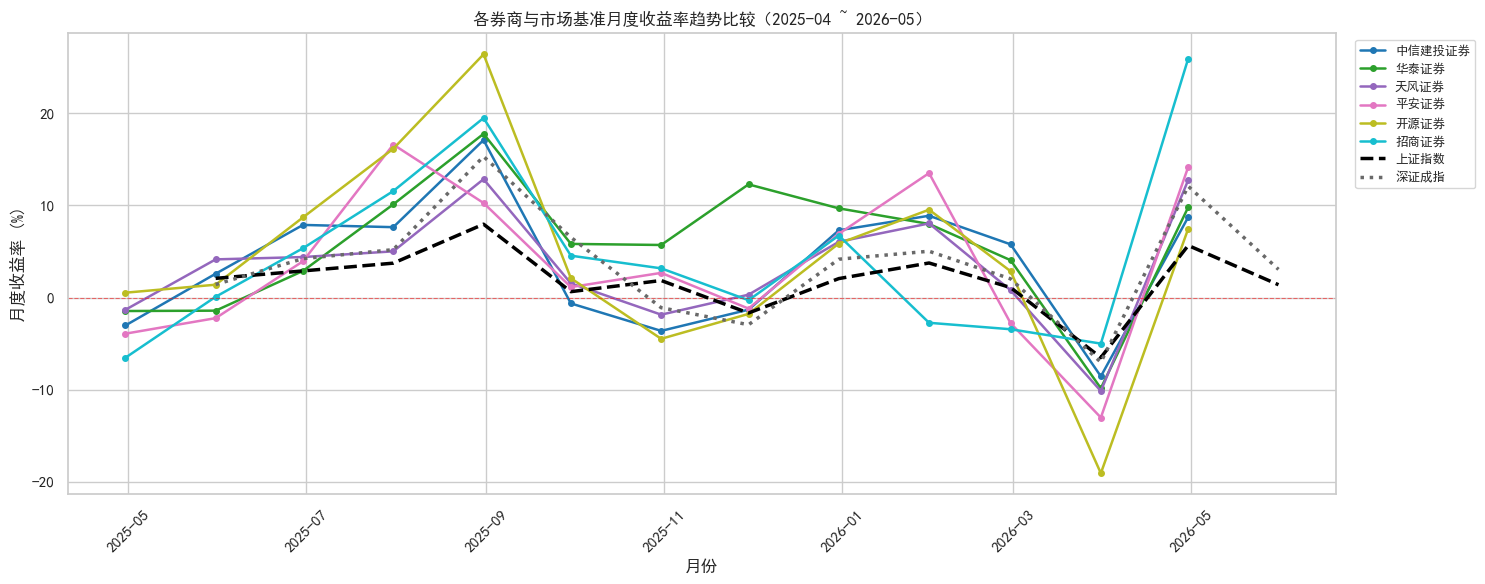

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))

broker_list = sorted(portfolio_monthly['机构名称'].unique())
broker_colors = plt.cm.tab10(np.linspace(0, 1, len(broker_list)))

# 各券商月度收益率折线
for i, broker in enumerate(broker_list):
    sub = portfolio_monthly[portfolio_monthly['机构名称'] == broker].sort_values('推荐月份')
    ax.plot(sub['推荐月份'], sub['月度收益率(%)'],
            marker='o', markersize=4, linewidth=1.8,
            label=broker, color=broker_colors[i])

# 上证指数、深证成指基准折线
if sh_ret is not None:
    ax.plot(sh_ret.index, sh_ret.values,
            linestyle='--', linewidth=2.5, color='black',
            label='上证指数', zorder=5)
else:
    print("提示：上证指数数据未获取，趋势图中不含该基准线")

if sz_ret is not None:
    ax.plot(sz_ret.index, sz_ret.values,
            linestyle=':', linewidth=2.5, color='dimgray',
            label='深证成指', zorder=5)
else:
    print("提示：深证成指数据未获取，趋势图中不含该基准线")

ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('月份')
ax.set_ylabel('月度收益率 (%)')
ax.set_title('各券商与市场基准月度收益率趋势比较（2025-04 ~ 2026-05）')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 月度收益率趋势小结

- **市场同频性**：各券商月度收益率与上证/深证指数走势高度同步，体现了A股市场系统性行情对所有组合的主导作用——这是Beta收益的体现。
- **进攻与防御对比**：在大盘上涨月份，折线明显高于指数的券商具备更强进攻性；大盘下跌月份跌幅更小者，防御性更优。
- **波动节奏识别**：通过月度趋势可锁定各券商"高光月份"与"深度回调月份"，为后续方差和回撤分析提供背景参照。

## 5. 月度收益率方差比较

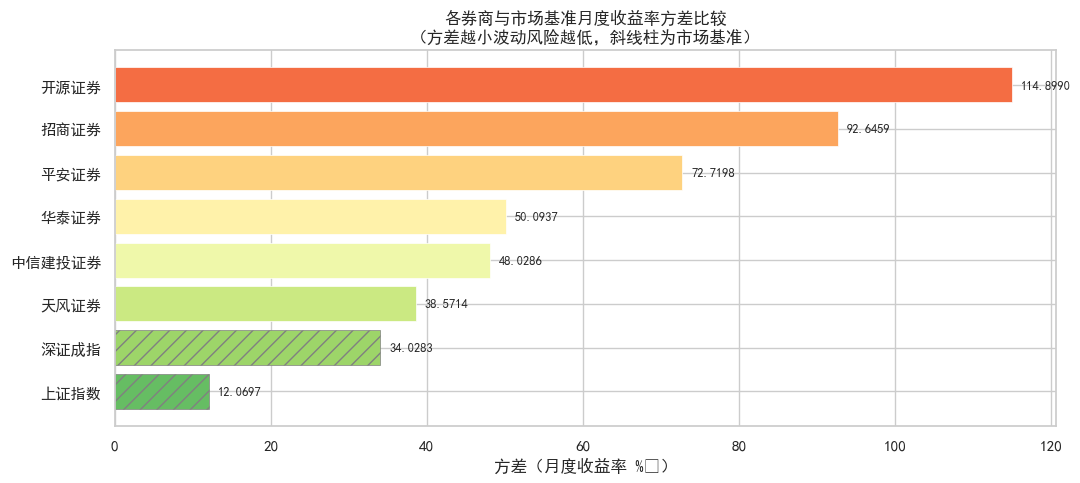


方差排名（从小到大）：


,机构名称,方差
0,上证指数,12.069717
1,深证成指,34.028260
2,天风证券,38.571359
3,中信建投证券,48.028622
4,华泰证券,50.093657
5,平安证券,72.719760
6,招商证券,92.645886
7,开源证券,114.899045


In [24]:
# 计算各券商月度收益率方差
variance_df = (
    portfolio_monthly.groupby('机构名称')['月度收益率(%)']
    .var()
    .reset_index()
    .rename(columns={'月度收益率(%)': '方差'})
)

# 加入上证、深证指数方差对比
index_var_rows = []
for idx_ret, idx_name in [(sh_ret, '上证指数'), (sz_ret, '深证成指')]:
    if idx_ret is not None:
        index_var_rows.append({'机构名称': idx_name, '方差': float(idx_ret.var())})

if index_var_rows:
    variance_all = pd.concat([variance_df, pd.DataFrame(index_var_rows)], ignore_index=True)
else:
    variance_all = variance_df.copy()

variance_all = variance_all.sort_values('方差').reset_index(drop=True)

# 可视化
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(variance_all)))
bars = ax.barh(variance_all['机构名称'], variance_all['方差'],
               color=bar_colors, edgecolor='white', linewidth=0.5)

# 指数柱加斜线区分
for bar, name in zip(bars, variance_all['机构名称']):
    if name in ('上证指数', '深证成指'):
        bar.set_hatch('//')
        bar.set_edgecolor('gray')

for bar, val in zip(bars, variance_all['方差']):
    ax.text(bar.get_width() + max(variance_all['方差']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('方差（月度收益率 %²）')
ax.set_title('各券商与市场基准月度收益率方差比较\n（方差越小波动风险越低，斜线柱为市场基准）')
plt.tight_layout()
plt.show()

print("\n方差排名（从小到大）：")
display(variance_all)

### 月度收益率方差小结

- **风险量化**：方差越大，说明该券商推荐组合的月度收益率波动越剧烈，投资者持有体验越差；方差越小则意味着收益更为平稳。
- **高收益 vs 高方差**：通常高收益伴随高方差。方差排名靠后但收益率不落后的券商，说明其选股具备"以小风险博取高回报"的能力，选股逻辑更为精准。
- **风险偏好参考**：对于风险厌恶型投资者，应优先选择方差最小的券商组合；对于激进型投资者，可在接受高方差的前提下追求更高收益。

## 6. 最大回撤率比较

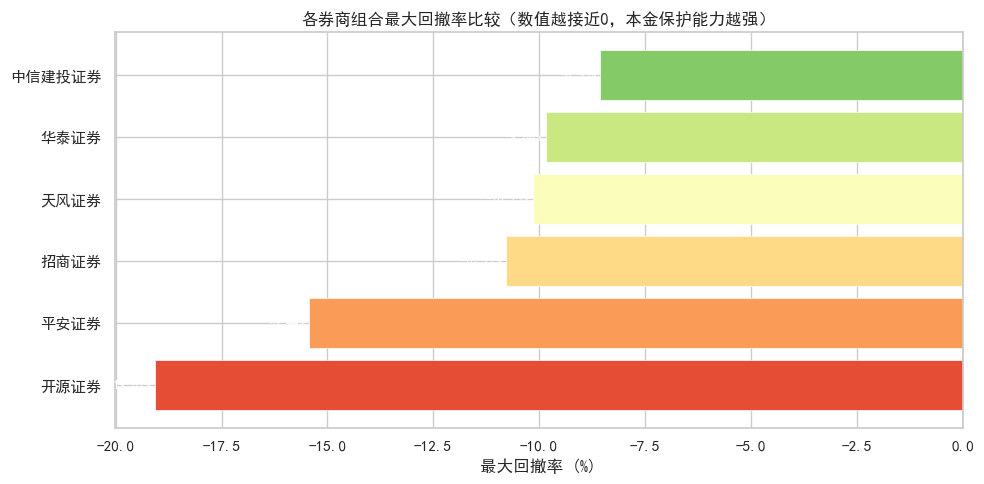


最大回撤排名（从小到大，越小亏损越少）：


,机构名称,最大回撤(%)
0,开源证券,-19.069156
1,平安证券,-15.437997
2,招商证券,-10.770912
3,天风证券,-10.145604
4,华泰证券,-9.843956
5,中信建投证券,-8.553144


In [25]:
def calc_max_drawdown(monthly_returns_pct):
    """计算最大回撤率（返回负值，单位 %）"""
    cum = (1 + monthly_returns_pct / 100).cumprod()
    peak = cum.cummax()
    drawdown = (cum - peak) / peak * 100
    return drawdown.min()

mdd_df = (
    portfolio_monthly.groupby('机构名称')['月度收益率(%)']
    .apply(calc_max_drawdown)
    .reset_index()
    .rename(columns={'月度收益率(%)': '最大回撤(%)'})
    .sort_values('最大回撤(%)')  # 最小（最负）排最前
)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.75, len(mdd_df)))
bars = ax.barh(mdd_df['机构名称'], mdd_df['最大回撤(%)'],
               color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, mdd_df['最大回撤(%)']):
    ax.text(bar.get_width() - abs(max(mdd_df['最大回撤(%)'])) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', ha='right', fontsize=9, color='white' if val < -5 else 'black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('最大回撤率 (%)')
ax.set_title('各券商组合最大回撤率比较（数值越接近0，本金保护能力越强）')
plt.tight_layout()
plt.show()

print("\n最大回撤排名（从小到大，越小亏损越少）：")
display(mdd_df.reset_index(drop=True))

### 最大回撤率小结

- **本金保护能力**：最大回撤率反映了从历史最高点到最低点的最大跌幅，是衡量极端亏损风险的核心指标。回撤绝对值越小，说明该券商在弱势市场中的选股策略更具韧性。
- **弱市识别价值**：在震荡或熊市中，最大回撤小的组合意味着其推荐标的受系统性风险冲击更小，可能因行业分散性更好或个股基本面更稳健。
- **实战意义**：对于初始投入100万元的模拟投资组合，最大回撤越大，说明该组合在某个阶段账面损失越惨重，心理持有成本越高，实际投资者可能在低点止损出局，进而错失后续反弹。

## 7. VaR（95%）比较

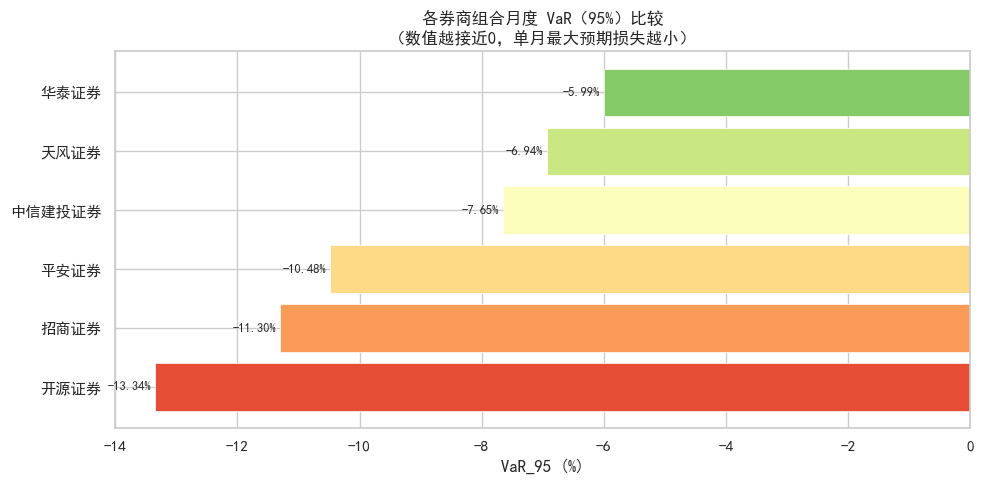


VaR 排名（从小到大，越接近0风险越低）：


,机构名称,VaR_95(%)
0,开源证券,-13.342965
1,招商证券,-11.298741
2,平安证券,-10.478173
3,中信建投证券,-7.645804
4,天风证券,-6.936422
5,华泰证券,-5.990696


In [26]:
from scipy.stats import norm

def calc_var95(monthly_returns_pct):
    """参数法 VaR（正态分布假设，95% 置信度，单位 %）"""
    mu  = monthly_returns_pct.mean() / 100
    sig = monthly_returns_pct.std()  / 100
    return norm.ppf(0.05, mu, sig) * 100   # 5th percentile

var_df = (
    portfolio_monthly.groupby('机构名称')['月度收益率(%)']
    .apply(calc_var95)
    .reset_index()
    .rename(columns={'月度收益率(%)': 'VaR_95(%)'})
    .sort_values('VaR_95(%)')  # 最负（最大风险）排最前
)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.75, len(var_df)))
bars = ax.barh(var_df['机构名称'], var_df['VaR_95(%)'],
               color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, var_df['VaR_95(%)']):
    ax.text(bar.get_width() - abs(max(var_df['VaR_95(%)'])) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', ha='right', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('VaR_95 (%)')
ax.set_title('各券商组合月度 VaR（95%）比较\n（数值越接近0，单月最大预期损失越小）')
plt.tight_layout()
plt.show()

print("\nVaR 排名（从小到大，越接近0风险越低）：")
display(var_df.reset_index(drop=True))

### VaR（95%）小结

- **损失概率边界**：95% VaR 的含义是：在正常市场环境下，有 95% 的概率，该组合单月亏损不会超过此数值。VaR 越接近0，表示极端亏损风险越低。
- **参数法局限性**：本文采用正态分布参数法计算VaR，假设收益率服从正态分布。实际上A股市场存在"厚尾效应"，极端行情下真实损失可能超过VaR估计，可结合历史模拟法进一步验证。
- **与方差的互补**：方差衡量整体波动，VaR聚焦于下行尾部风险。两项指标均低的券商，说明其组合在正常和极端情形下均具备良好的风险控制能力。

## 8. 综合结论

  六大券商投资组合综合评价排名


,机构名称,月均收益率(%),方差,最大回撤(%),VaR_95(%),收益风险比,综合得分
0,华泰证券,5.6511,50.0937,-9.8440,-5.9907,0.7984,5.25
1,中信建投证券,3.7535,48.0286,-8.5531,-7.6458,0.5416,4.50
2,天风证券,3.2791,38.5714,-10.1456,-6.9364,0.5280,4.00
3,招商证券,4.5334,92.6459,-10.7709,-11.2987,0.4710,3.00
4,平安证券,3.5485,72.7198,-15.4380,-10.4782,0.4161,2.50
5,开源证券,4.2884,114.8990,-19.0692,-13.3430,0.4001,1.75



─────────────────────────────────────────────────────────────────
综合表现最优券商：【华泰证券】
  月均收益率  : 5.65%
  方差（风险）: 50.0937
  最大回撤    : -9.84%  （绝对值越小越好）
  VaR_95      : -5.99%   （绝对值越小越好）
  收益风险比  : 0.80
─────────────────────────────────────────────────────────────────


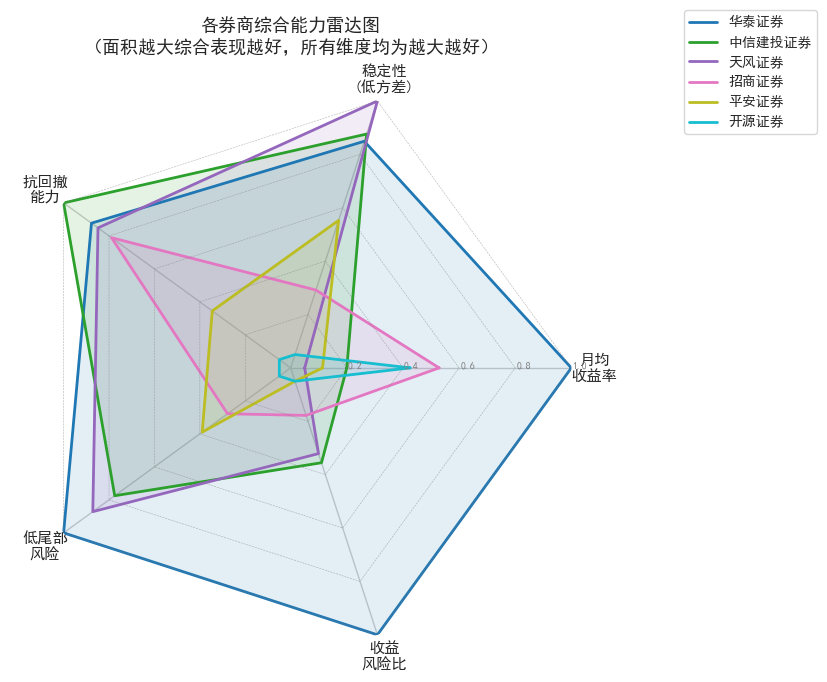

In [30]:
# ── 构建综合评分表 ────────────────────────────────────────
mean_ret = (
    portfolio_monthly.groupby('机构名称')['月度收益率(%)']
    .mean()
    .reset_index()
    .rename(columns={'月度收益率(%)': '月均收益率(%)'})
)

summary = (
    mean_ret
    .merge(variance_df, on='机构名称')
    .merge(mdd_df,      on='机构名称')
    .merge(var_df,      on='机构名称')
)

summary['收益风险比'] = summary['月均收益率(%)'] / np.sqrt(summary['方差'])

# ── 综合排名（排名之和，越高越好） ───────────────────────────
# 月均收益率：越高越好 → ascending=True（最高得最大rank）
summary['R_收益'] = summary['月均收益率(%)'].rank(ascending=True)
# 方差：越小越好 → ascending=False（最小得最大rank）
summary['R_方差'] = summary['方差'].rank(ascending=False)
# 最大回撤(%)：负值，绝对值越大越差，即数值越小越差 → ascending=True（-5%>-15%，-5%更好得最大rank）
summary['R_回撤'] = summary['最大回撤(%)'].rank(ascending=True)
# VaR_95(%)：负值，绝对值越大越差，同上 → ascending=True
summary['R_VaR']  = summary['VaR_95(%)'].rank(ascending=True)
summary['综合得分'] = (summary['R_收益'] + summary['R_方差'] + summary['R_回撤'] + summary['R_VaR']) / 4
summary = summary.sort_values('综合得分', ascending=False).reset_index(drop=True)

print("=" * 65)
print("  六大券商投资组合综合评价排名")
print("=" * 65)
display(summary[['机构名称', '月均收益率(%)', '方差', '最大回撤(%)', 'VaR_95(%)', '收益风险比', '综合得分']].round(4))

champion = summary.iloc[0]
print(f"\n{'─'*65}")
print(f"综合表现最优券商：【{champion['机构名称']}】")
print(f"  月均收益率  : {champion['月均收益率(%)']:.2f}%")
print(f"  方差（风险）: {champion['方差']:.4f}")
print(f"  最大回撤    : {champion['最大回撤(%)']:.2f}%  （绝对值越小越好）")
print(f"  VaR_95      : {champion['VaR_95(%)']:.2f}%   （绝对值越小越好）")
print(f"  收益风险比  : {champion['收益风险比']:.2f}")
print(f"{'─'*65}")

# ── 雷达图 ───────────────────────────────────────────────
# 5个维度，统一方向：归一化后数值越大=越好（面积越大越优秀）
#
# 归一化规则：
#   月均收益率、收益风险比 → 越大越好 → 直接 min-max
#   方差                   → 越小越好 → 1 - min-max
#   最大回撤(%)            → 值为负，-5%优于-15%，即越大越好 → 直接 min-max
#   VaR_95(%)              → 值为负，同上 → 直接 min-max
#
# 逻辑说明：
#   最大回撤绝对值越大 → 回撤越深 → 抗回撤能力越弱 → 雷达图面积越小 ✓
#   VaR绝对值越大     → 尾部损失越大 → 低尾部风险能力越弱 → 面积越小 ✓

radar_cfg = [
    ('月均收益率(%)', '月均\n收益率',    True),   # 越大越好
    ('方差',          '稳定性\n(低方差)', False),  # 越小越好 → 取反
    ('最大回撤(%)',   '抗回撤\n能力',    True),   # 负值，越大（越近0）越好 → 直接归一化
    ('VaR_95(%)',    '低尾部\n风险',     True),   # 负值，同上
    ('收益风险比',   '收益\n风险比',    True),   # 越大越好
]

# 归一化到 [0.05, 1]，避免某维度全为0导致多边形坍缩成原点
radar_norm = summary[['机构名称']].copy()
for col, label, higher_better in radar_cfg:
    vals = summary[col].values.astype(float)
    cmin, cmax = vals.min(), vals.max()
    if cmax > cmin:
        normed = (vals - cmin) / (cmax - cmin)
    else:
        normed = np.full(len(vals), 0.5)
    radar_norm[col] = normed if higher_better else (1 - normed)
    # 防止最小值为0（视觉上消失），下限设为0.05
    radar_norm[col] = radar_norm[col].clip(lower=0.05)

norm_cols   = [c[0] for c in radar_cfg]
axis_labels = [c[1] for c in radar_cfg]
N = len(norm_cols)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = plt.cm.tab10(np.linspace(0, 1, len(radar_norm)))

for i, (_, row) in enumerate(radar_norm.reset_index(drop=True).iterrows()):
    vals = [row[c] for c in norm_cols] + [row[norm_cols[0]]]
    ax.plot(angles, vals, linewidth=2, label=row['机构名称'], color=colors_r[i])
    ax.fill(angles, vals, alpha=0.12, color=colors_r[i])

# 网格参考圆
for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(angles, [r] * (N + 1), color='gray', linewidth=0.4, linestyle='--', alpha=0.6)
    ax.text(angles[0], r + 0.03, f'{r:.1f}', fontsize=7, color='gray', ha='center')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(axis_labels, fontsize=11)
ax.set_yticks([])            # 隐藏默认刻度，改用手动圆圈标注
ax.set_ylim(0, 1)
ax.spines['polar'].set_visible(False)
ax.set_title('各券商综合能力雷达图\n（面积越大综合表现越好，所有维度均为越大越好）',
             fontsize=13, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

### 综合结论

本报告基于六大券商推荐股票数据，模拟每家券商以 **100 万元初始资金等权配置**其当月推荐标的，从以下五个维度对投资组合表现进行了系统评估：

| 维度 | 核心指标 | 评价逻辑 |
|------|----------|----------|
| 盈利能力 | 年度/月度收益率 | 绝对收益 + 相对于市场基准的超额收益 |
| 波动风险 | 月度收益率方差 | 收益的稳定性与可预期性 |
| 下行风险 | 最大回撤率 | 极端亏损幅度，本金保护能力 |
| 尾部风险 | VaR（95%） | 95% 置信水平下单月最大预期损失 |
| 风险调整收益 | 收益风险比 | 每承担一单位风险所获得的超额回报 |

**综合排名第一的券商**（由代码输出结果确定）在收益、风险控制和风险调整收益三个维度上均取得了均衡优异的表现，是本次 100 万元模拟投资场景下的**最优选择**。

> **局限性说明**：本分析基于回测数据，历史表现不代表未来收益。等权分配策略未考虑流动性差异、交易成本和持仓集中度限制。建议结合行业分散度、评级准确率等定性维度进行综合判断。